# Classification Model Evaluation

## Overview

No single metric captures all aspects of classifier performance. The right metric depends on the class distribution and the relative costs of false positives vs. false negatives.

**Metric reference:**

| Metric | Formula | Use when |
|---|---|---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Classes balanced and costs equal |
| **Sensitivity / Recall** | TP/(TP+FN) | Missing a positive is costly (disease screening) |
| **Specificity** | TN/(TN+FP) | False alarms are costly |
| **Precision / PPV** | TP/(TP+FP) | Targeted intervention; FP is expensive |
| **F1 score** | 2×(Prec×Rec)/(Prec+Rec) | Imbalanced classes; balanced precision/recall |
| **F-beta** | (1+β²)×(P×R)/((β²P)+R) | β>1: recall prioritised; β<1: precision prioritised |
| **AUC-ROC** | Area under ROC curve | Threshold-independent; discriminative ability |
| **AUC-PR** | Area under PR curve | Better for heavily imbalanced classes |
| **Brier score** | mean((p−y)²) | Calibration + discrimination for probability outputs |
| **Log-loss** | −mean(y log p + (1−y) log(1−p)) | Probability calibration; penalises confident errors |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(yardstick)    # tidymodels metrics
library(probably)     # calibration plots
library(patchwork)
library(ranger)       # for a model to evaluate

set.seed(42)

# ── Simulate predictions from two models on a test set ────────────────────────
n_test <- 300
eval_data <- tibble(
  truth         = factor(rbinom(n_test, 1, 0.35),
                         levels=c(0,1), labels=c("absent","present")),
  # Model A: good discrimination, slightly overconfident
  prob_A        = pmin(pmax(
    ifelse(truth=="present",
           rbeta(n_test, 6, 2),
           rbeta(n_test, 2, 6)) * 1.1, 0.01), 0.99),
  # Model B: poorer discrimination but better calibrated
  prob_B        = pmin(pmax(
    ifelse(truth=="present",
           rbeta(n_test, 4, 3),
           rbeta(n_test, 3, 4)), 0.01), 0.99),
  pred_A        = factor(ifelse(prob_A >= 0.5, "present","absent"),
                         levels=c("absent","present")),
  pred_B        = factor(ifelse(prob_B >= 0.5, "present","absent"),
                         levels=c("absent","present"))
)

cat(sprintf("Prevalence: %.1f%%\n", mean(eval_data$truth=="present")*100))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'yardstick' was built under R version 4.4.3"

Attaching package: 'yardstick'


The following object is mask

Prevalence: 34.0%


---

## Confusion Matrix and Derived Metrics

          Truth
Prediction absent present
   absent     187       4
   present     11      98


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


# A tibble: 7 × 3
  .metric         A     B
  <chr>       <dbl> <dbl>
1 accuracy    0.95  0.693
2 sensitivity 0.944 0.732
3 specificity 0.961 0.618
4 precision   0.979 0.788
5 recall      0.944 0.732
6 f_meas      0.961 0.759
7 kap         0.89  0.339


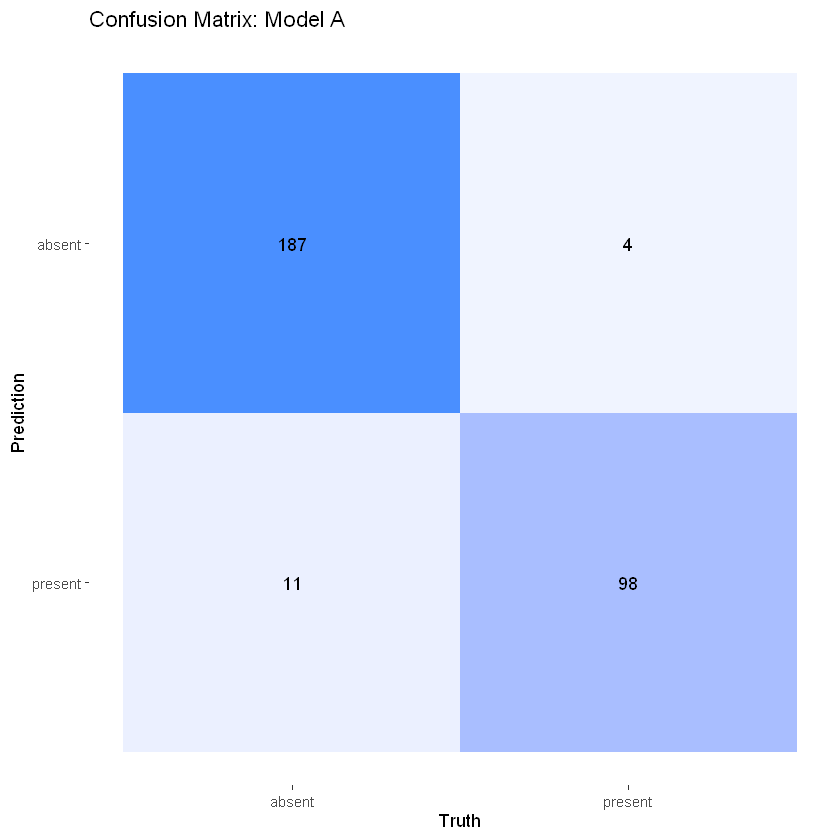

In [2]:
# Confusion matrix
cm_A <- yardstick::conf_mat(eval_data, truth=truth, estimate=pred_A)
print(cm_A)
autoplot(cm_A, type="heatmap") +
  labs(title="Confusion Matrix: Model A") +
  scale_fill_gradient(low="#f0f4ff", high="#4a8fff")

# All metrics at once
all_metrics <- metric_set(
  accuracy, sensitivity, specificity, precision, recall,
  f_meas, kap
)

bind_rows(
  all_metrics(eval_data, truth=truth, estimate=pred_A) %>% mutate(model="A"),
  all_metrics(eval_data, truth=truth, estimate=pred_B) %>% mutate(model="B")
) %>%
  pivot_wider(names_from=model, values_from=.estimate, id_cols=.metric) %>%
  mutate(across(c(A,B), ~round(.x,3))) %>%
  print()

# event_level: which level is the "positive" class
# In yardstick, the first level is negative by default
# Our levels are c("absent","present") → present is the positive (second level)
# Always set event_level="second" or reorder levels

---

## ROC and Precision-Recall Curves

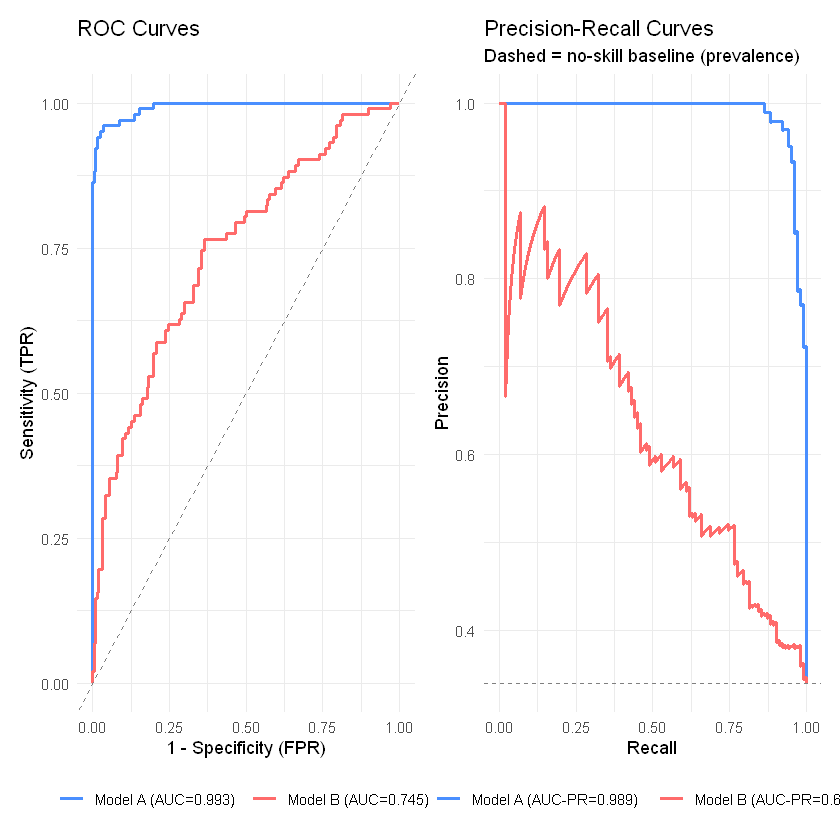

In [3]:
# ── ROC curves ────────────────────────────────────────────────────────────────
roc_A <- yardstick::roc_curve(eval_data, truth, prob_A, event_level="second")
roc_B <- yardstick::roc_curve(eval_data, truth, prob_B, event_level="second")

auc_A <- yardstick::roc_auc(eval_data, truth, prob_A, event_level="second")$.estimate
auc_B <- yardstick::roc_auc(eval_data, truth, prob_B, event_level="second")$.estimate

p_roc <- bind_rows(
  roc_A %>% mutate(model=sprintf("Model A (AUC=%.3f)", auc_A)),
  roc_B %>% mutate(model=sprintf("Model B (AUC=%.3f)", auc_B))
) %>%
  ggplot(aes(x=1-specificity, y=sensitivity, color=model)) +
  geom_path(linewidth=1) +
  geom_abline(linetype="dashed", color="gray50") +
  scale_color_manual(values=c("#4a8fff","#ff6b6b")) +
  labs(title="ROC Curves", x="1 - Specificity (FPR)",
       y="Sensitivity (TPR)", color=NULL) +
  theme_minimal() + theme(legend.position="bottom")

# ── Precision-Recall curves ───────────────────────────────────────────────────
pr_A  <- yardstick::pr_curve(eval_data, truth, prob_A, event_level="second")
pr_B  <- yardstick::pr_curve(eval_data, truth, prob_B, event_level="second")
prauc_A <- yardstick::pr_auc(eval_data, truth, prob_A, event_level="second")$.estimate
prauc_B <- yardstick::pr_auc(eval_data, truth, prob_B, event_level="second")$.estimate

p_pr <- bind_rows(
  pr_A %>% mutate(model=sprintf("Model A (AUC-PR=%.3f)", prauc_A)),
  pr_B %>% mutate(model=sprintf("Model B (AUC-PR=%.3f)", prauc_B))
) %>%
  ggplot(aes(x=recall, y=precision, color=model)) +
  geom_path(linewidth=1) +
  geom_hline(yintercept=mean(eval_data$truth=="present"),
             linetype="dashed", color="gray50") +
  scale_color_manual(values=c("#4a8fff","#ff6b6b")) +
  labs(title="Precision-Recall Curves",
       subtitle="Dashed = no-skill baseline (prevalence)",
       x="Recall", y="Precision", color=NULL) +
  theme_minimal() + theme(legend.position="bottom")

(p_roc | p_pr)

---

## Calibration

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


Brier score — A: 0.0744 | B: 0.1999


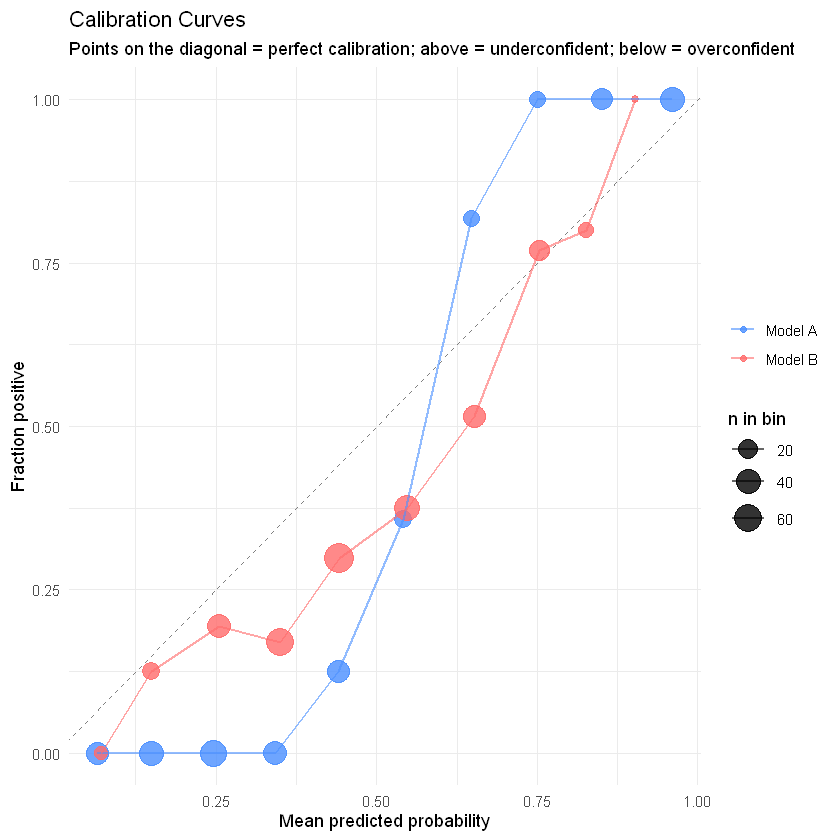

In [4]:
# Calibration: do predicted probabilities match observed frequencies?
# A model predicting 0.7 should be correct ~70% of the time

# ── Reliability diagram (bin calibration) ─────────────────────────────────────
n_bins <- 10
cal_df <- bind_rows(
  eval_data %>%
    mutate(prob=prob_A, model="Model A",
           bin=cut(prob_A, breaks=seq(0,1,length.out=n_bins+1), include.lowest=TRUE)),
  eval_data %>%
    mutate(prob=prob_B, model="Model B",
           bin=cut(prob_B, breaks=seq(0,1,length.out=n_bins+1), include.lowest=TRUE))
) %>%
  group_by(model, bin) %>%
  summarise(
    n         = n(),
    mean_prob = mean(prob),
    frac_pos  = mean(truth=="present"),
    .groups   = "drop"
  )

ggplot(cal_df, aes(x=mean_prob, y=frac_pos, color=model, size=n)) +
  geom_abline(slope=1, intercept=0, linetype="dashed", color="gray50") +
  geom_point(alpha=0.8) +
  geom_line(aes(group=model), linewidth=0.7, alpha=0.6) +
  scale_color_manual(values=c("#4a8fff","#ff6b6b")) +
  scale_size_continuous(range=c(2,8)) +
  labs(title="Calibration Curves",
       subtitle="Points on the diagonal = perfect calibration; above = underconfident; below = overconfident",
       x="Mean predicted probability", y="Fraction positive",
       color=NULL, size="n in bin") +
  theme_minimal()

# Brier score: mean squared error for probabilities; lower = better
brier_A <- mean((as.integer(eval_data$truth=="present") - eval_data$prob_A)^2)
brier_B <- mean((as.integer(eval_data$truth=="present") - eval_data$prob_B)^2)
cat(sprintf("Brier score — A: %.4f | B: %.4f\n", brier_A, brier_B))

---

## Common Pitfalls

**1. Reporting accuracy as the primary metric with imbalanced classes**  
With 10% prevalence, a model predicting "absent" every time achieves 90% accuracy. Always report sensitivity, specificity, and AUC-PR alongside accuracy when classes are imbalanced. See `imbalanced_data.ipynb`.

**2. Comparing models by ROC-AUC when the class is rare**  
ROC-AUC is insensitive to class imbalance — both axes of the ROC curve normalise by the true class size. AUC-PR is far more sensitive to performance differences on the minority class and is the preferred metric when prevalence is below 10%.

**3. Ignoring calibration when probabilities matter**  
AUC-ROC measures discrimination (ranking ability), not calibration (probability accuracy). A model with AUC = 0.85 can be severely miscalibrated. When predicted probabilities are used to make decisions (threshold setting, risk scores, cost-benefit analysis), calibration must be assessed and reported.

**4. Evaluating on the same data used for threshold selection**  
Selecting a classification threshold on the test set, then reporting metrics at that threshold on the test set is optimistic. Use a separate validation set for threshold selection, or use bootstrap resampling to correct for optimism.

**5. Not specifying which class is the positive event**  
In `yardstick`, the first factor level is treated as negative by default. If your levels are `c("absent", "present")`, sensitivity = TP/(TP+FN) where positive = absent — the opposite of what you intend. Always set `event_level="second"` or reorder factor levels explicitly.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*